# Final-correction path-gap: code-capacity experiments

`phase2a_getting_started.ipynb` と同じ現行グリッド・ノイズ・サンプリング設定で、新しい **path-gap** を評価します。SWIM とは別の heuristic であり、exact logical gap / posterior LLR ではありません。

通常の **color_code_so** カーネルで実行できます。path-gap のソースは自動で読み込まれます。環境切替やパッケージの再インストールは不要です。既存の SWIM decoder / PyMatching はそのまま使います。詳細は `../notes/support/PATH_GAP_EXPERIMENT.md` を参照。

`RUN_NEW_EXPERIMENT=True` のときは設定したショット数で新規 sampling を実行します。保存済みデータの解析だけを行う場合は `False` にしてください。付属の検証データは各点128ショットの smoke で、性能の優劣を判定するには不足しています。


In [1]:
from pathlib import Path
from IPython.display import display
from color_code_softoutput.experiments.path_gap_test import PathGapTestConfig, run_experiment, require_path_gap
from color_code_softoutput.simulation.config import PROJECT_ROOT
from color_code_softoutput.analysis.path_gap import PathGapDataset, audit_run, matched_retention
from color_code_softoutput.analysis.swim_distribution import SwimDistanceDistributionPlotter
from color_code_softoutput.analysis.conditional_ler import ConditionalLERAnalyzer
from color_code_softoutput.analysis.postselection import PostSelectionAnalyzer
from color_code_softoutput.analysis.prior_work import LeeFig3ReproductionAnalyzer
from color_code_softoutput.analysis.figure_style import RevtexFigureStyle

style = RevtexFigureStyle()  # same publication style / 99% Wilson bands
require_path_gap()


_color_code_softoutput_path_gap.metrics.monochromatic_path_gap.ColorCodePathGap

In [2]:
metric_version = "v1"  # "v1": 全 correction weight を減算 / "v2": path overlap の weight を減算
shots_per_point = 1_000_000
num_workers = 8
batch_size = 2_000
master_seed = 0
config = PathGapTestConfig(distances=(9, 13, 15), shots_per_point=shots_per_point, num_workers=num_workers,
                          near_threshold_ps=(), subthreshold_ps=(0.04, 0.05), batch_size=batch_size, master_seed=master_seed)
print('Full experiment shots:', len(config.distances)*len(config.probabilities)*config.shots_per_point)
config.resolved()


Full experiment shots: 6000000


{'distances': (9, 13, 15),
 'near_threshold_ps': (),
 'subthreshold_ps': (0.04, 0.05),
 'shots_per_point': 1000000,
 'batch_size': 2000,
 'num_workers': 8,
 'master_seed': 0,
 'output_root': '/home/quantum_teresheys/workspace/color_code_softoutput/results',
 'verbose': True}

## 実験の実行・再読込

同じ物理ショットを ordinary / comparative の双方で復号し、各デコーダの **最終訂正** から soft output を計算します。設定セルの `metric_version` を `run_experiment(..., metric_version=metric_version)` に渡して方式を選びます。

- `"v1"` (`global_subtraction_v1`): `phi=min_c [D_c(E)-W(E)]`。correction 全体の weight を引きます。この notebook ではこちらを選択しています。
- `"v2"` (`path_overlap_v2`): `phi=min_c [D_c(E)-W(E ∩ L_c)]`。返された path 上の correction の weight だけを引きます。

新規 run は選択した方式を metadata と各 shot に記録します。両方式とも残余距離・全 correction weight・path overlap を保存し、負値もそのまま扱います。失敗ショットのスコアは符号反転しません。`metric_version` は新規 sampling に適用され、保存済みデータの再読込ではその run の記録済み方式を使います。既存の未バージョン化データは v1 のままです。下に残っている既存の図・表は以前の実行結果です。


In [3]:
RUN_NEW_EXPERIMENT = True
SMOKE = False  # True: full grid, but 128 shots/point
existing_run = Path('/home/quantum_teresheys/workspace/color_code_softoutput/results/20260919_002159_907598_path_gap_test')  # or Path('/absolute/path/to/a/completed_path_gap_test')
if RUN_NEW_EXPERIMENT:
    from dataclasses import replace
    run_directory = run_experiment(replace(config, shots_per_point=128) if SMOKE else config,
                                   metric_version=metric_version)
elif existing_run is not None:
    run_directory = Path(existing_run)
else:
    import json
    candidates = [p.parent for p in config.output_root.glob('*_path_gap_test/metadata.json')
                  if json.loads(p.read_text()).get('status') == 'sampling_complete']
    if not candidates:
        raise FileNotFoundError('Run the documented --smoke command or set RUN_NEW_EXPERIMENT=True.')
    run_directory = sorted(candidates)[-1]
dataset = PathGapDataset(run_directory)
print(run_directory)
print('Saved metric version:', dataset.metric_version)
print('Actual saved shots/point:', dataset.metadata['resolved_config']['shots_per_point'])
dataset.available_values()


path-gap: 2000/6000000 shots; 9.2s
path-gap: 4000/6000000 shots; 9.3s
path-gap: 6000/6000000 shots; 9.4s
path-gap: 8000/6000000 shots; 9.6s
path-gap: 10000/6000000 shots; 9.7s
path-gap: 12000/6000000 shots; 9.8s
path-gap: 14000/6000000 shots; 9.8s
path-gap: 16000/6000000 shots; 9.9s
path-gap: 18000/6000000 shots; 10.3s
path-gap: 20000/6000000 shots; 10.4s
path-gap: 22000/6000000 shots; 10.5s
path-gap: 24000/6000000 shots; 10.6s
path-gap: 26000/6000000 shots; 10.7s
path-gap: 28000/6000000 shots; 10.8s
path-gap: 30000/6000000 shots; 10.9s
path-gap: 32000/6000000 shots; 11.2s
path-gap: 34000/6000000 shots; 11.6s
path-gap: 36000/6000000 shots; 11.7s
path-gap: 38000/6000000 shots; 11.8s
path-gap: 40000/6000000 shots; 11.9s
path-gap: 42000/6000000 shots; 12.1s
path-gap: 44000/6000000 shots; 12.2s
path-gap: 46000/6000000 shots; 12.3s
path-gap: 48000/6000000 shots; 12.6s
path-gap: 50000/6000000 shots; 13.6s
path-gap: 52000/6000000 shots; 13.7s
path-gap: 54000/6000000 shots; 13.9s
path-gap: 560

{'distance': [9, 13, 15], 'physical_error_rate': [0.04, 0.05]}

In [5]:
REPLAY = False  # True replays the first saved batch of EVERY (d,p); no new independent sample
report = audit_run(dataset, replay=REPLAY)
display(report)
if report['source_drift']:
    print('Source files have changed; see source_snapshot.zip for the exact run sources.')
prior = LeeFig3ReproductionAnalyzer(style).analyze(dataset)
display(prior['crossing'], prior['fits'], prior['trends'])


{'passed': True,
 'shots': 4000000,
 'batches': 2000,
 'replayed_batches': 0,
 'source_drift': [],
 'exact_source_match': True}

{'threshold': 0.088,
 'variance': 3.441959437782059e-06,
 'status': 'endpoint_minimum',
 'estimator': 'minimum variance across LOWESS frac=2/3 curves on 2001-point common linear grid',
 'search_interval': [0.082, 0.088]}

,distance,points_used,points_excluded,excluded_probabilities,fit_status,total_failures,G,C,G_se,C_se,G_low,G_high,C_low,C_high
0,5,4,0,[],ok,4671,2.657545,4.259731,0.054772,0.187618,2.113946,3.201144,2.397648,6.121813
1,7,4,0,[],ok,2799,3.483627,6.343427,0.057065,0.195475,2.917266,4.049989,4.403371,8.283482
2,9,4,0,[],ok,1714,4.596872,9.349014,0.124925,0.427926,3.357013,5.836731,5.101911,13.596117
3,11,4,0,[],ok,1105,5.181141,10.657395,0.100864,0.345507,4.180082,6.182200,7.228295,14.086494


,parameter,distances_used,fit_status,slope,intercept,slope_se,slope_low,slope_high
0,G,4,ok,0.434202,0.506183,0.034613,0.090673,0.777730
1,C,4,ok,1.109929,-1.227040,0.111048,0.007800,2.212058


## 分布・条件付き logical error rate

ordinary path-gap は ordinary の失敗ラベルに対応します。`o`: success、`x`: failure。負の値も実際のスコアです。条件付き LER の logistic fit は経験的なモデルであり、較正の保証ではありません。


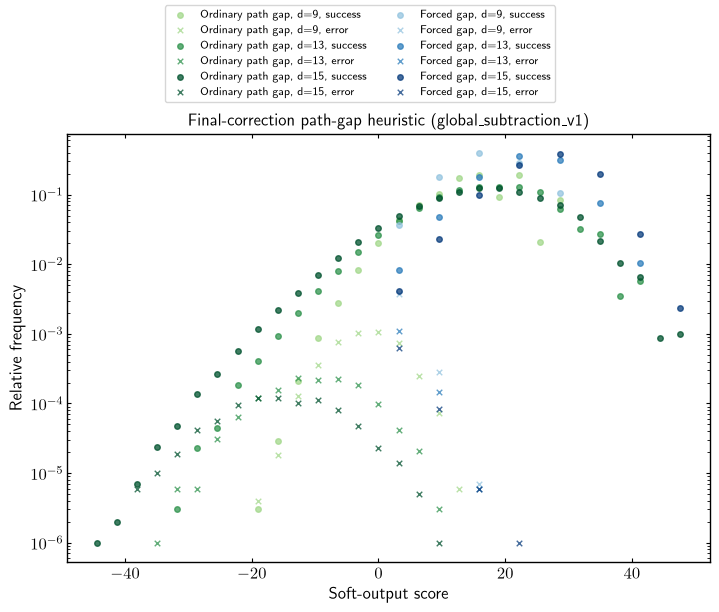

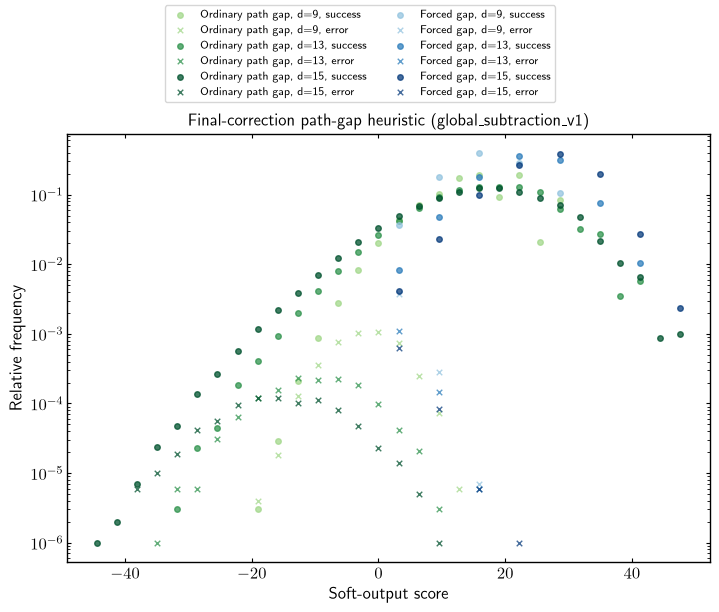

In [4]:
values = dataset.available_values()
distances = [d for d in (9, 13, 15) if d in values['distance']] or values['distance']
p = .04 if .04 in values['physical_error_rate'] else values['physical_error_rate'][0]
selection = dict(distance=distances, physical_error_rate=p)
include_forced_gap = True  # False: show only ordinary path gap
figure, distribution = SwimDistanceDistributionPlotter(style).plot(
    dataset, **selection, metric='ordinary_path_gap', normalize_frequency=True,
    include_forced_gap=include_forced_gap)
distribution_filename = ('path_gap_with_forced_gap_distribution_counts.parquet'
                         if include_forced_gap else 'path_gap_distribution_counts.parquet')
distribution.to_parquet(run_directory / distribution_filename, index=False)
display(figure)


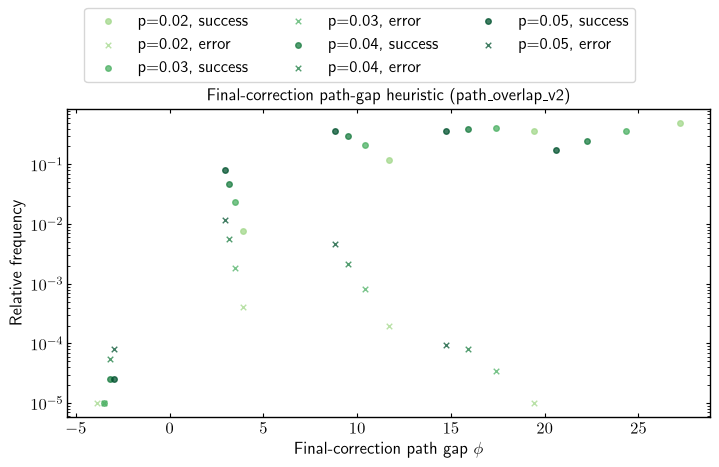

In [5]:
fixed_d = 7 if 7 in values['distance'] else values['distance'][0]
probabilities = [p for p in (.02, .03, .04, .05) if p in values['physical_error_rate']]
figure, distribution_p = SwimDistanceDistributionPlotter(style).plot(
    dataset, distance=fixed_d, physical_error_rate=probabilities or values['physical_error_rate'],
    metric='ordinary_path_gap', normalize_frequency=True)
distribution_p.to_parquet(run_directory / 'path_gap_distribution_p_counts.parquet', index=False)
display(figure)


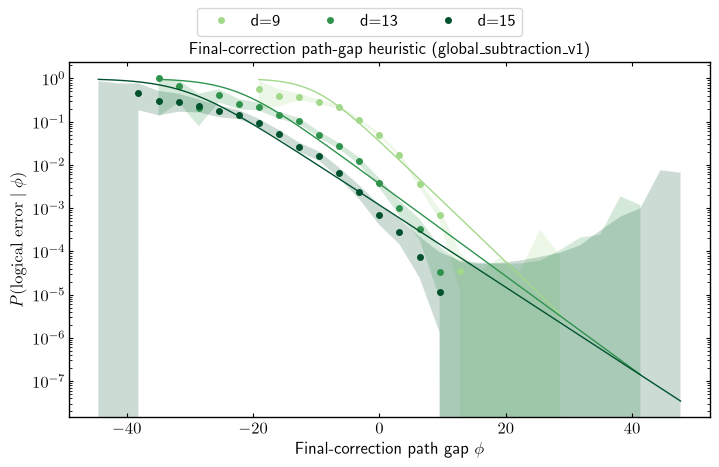

,shots,failures,fit_status,k,l,k_se,l_se,k_low,k_high,l_low,l_high,distance,physical_error_rate,varying_parameter,varying_value
0,1000000,4397,ok,0.322582,3.315410,0.002691,0.016595,0.315652,0.329513,3.272665,3.358156,9,0.04,distance,9
1,1000000,1407,ok,0.246315,5.602802,0.003095,0.038273,0.238344,0.254287,5.504218,5.701387,13,0.04,distance,13
2,1000000,852,ok,0.219124,6.739300,0.003336,0.057371,0.210530,0.227717,6.591523,6.887077,15,0.04,distance,15


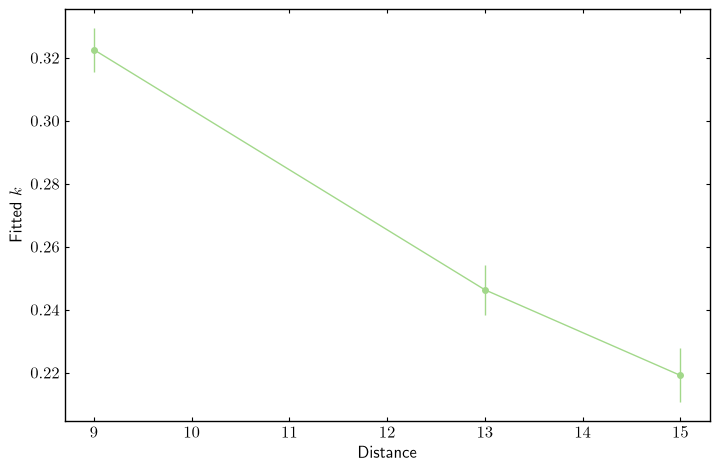

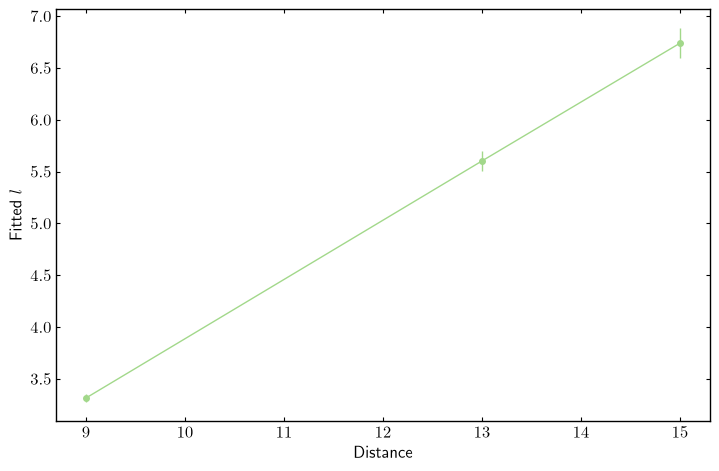

In [5]:
conditional = ConditionalLERAnalyzer(style)
figure, rates, fits = conditional.plot(dataset, **selection, metric='ordinary_path_gap')
rates.to_parquet(run_directory / 'path_gap_conditional_rates.parquet', index=False)
display(figure, fits)
for figure in conditional.plot_parameters(fits, output_directory=run_directory / 'figures', suffix='path_gap_distance'):
    display(figure)


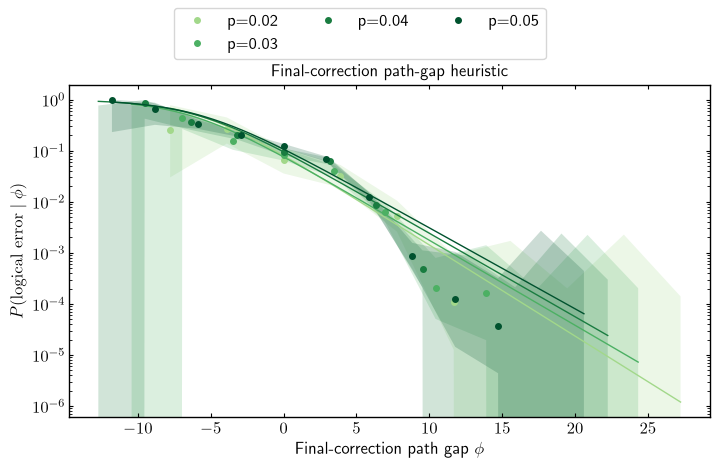

,shots,failures,fit_status,k,l,k_se,l_se,k_low,k_high,l_low,l_high,distance,physical_error_rate,varying_parameter,varying_value
0,100000,70,ok,0.411014,2.439564,0.023068,0.143838,0.351594,0.470434,2.069062,2.810066,7,0.02,physical_error_rate,0.02
1,100000,269,ok,0.383524,2.502002,0.012464,0.070386,0.351419,0.415629,2.320701,2.683303,7,0.03,physical_error_rate,0.03
2,100000,785,ok,0.376827,2.251385,0.008345,0.041024,0.355332,0.398323,2.145713,2.357057,7,0.04,physical_error_rate,0.04
3,100000,1675,ok,0.365430,2.121772,0.006234,0.027660,0.349372,0.381489,2.050523,2.193021,7,0.05,physical_error_rate,0.05


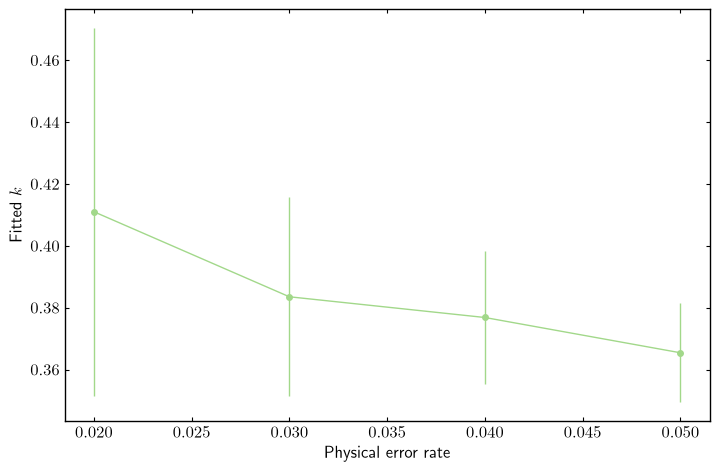

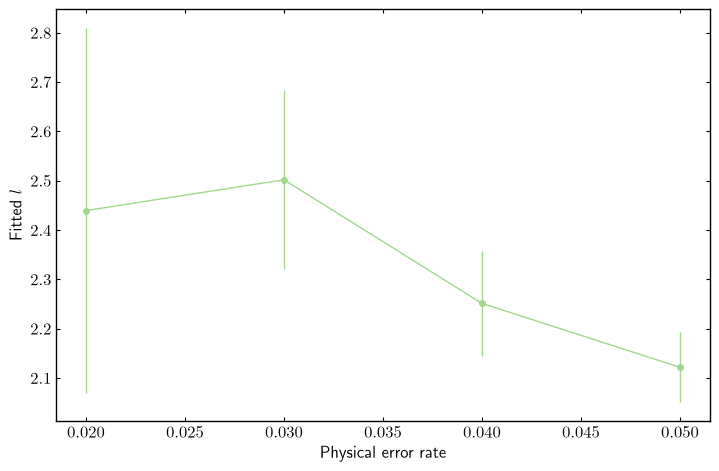

In [9]:
figure, rates_p, fits_p = conditional.plot(
    dataset, distance=fixed_d, physical_error_rate=probabilities or values['physical_error_rate'],
    metric='ordinary_path_gap')
rates_p.to_parquet(run_directory / 'path_gap_conditional_p_rates.parquet', index=False)
display(figure, fits_p)
for figure in conditional.plot_parameters(fits_p, output_directory=run_directory / 'figures', suffix='path_gap_probability'):
    display(figure)


## Post-selection: threshold と同一保持率での比較

主図は `score >= threshold` を保持し、同点はまとめて残します。左端は棄却なし。Wilson帯は99%の点ごとの区間であり、曲線全体や手法間差の信頼区間ではありません。ゼロ失敗も保存テーブル・区間に残します（対数軸にゼロの点は描けません）。

1. ordinary path-gap の性能。
2. ordinary path-gap vs comparative forced gap：物理ショットは同じですが **hard decoder と失敗ラベルは異なります**。
3. comparative path-gap vs forced gap：**同じ hard decoder・同じ失敗ラベル**でスコアを比較します。


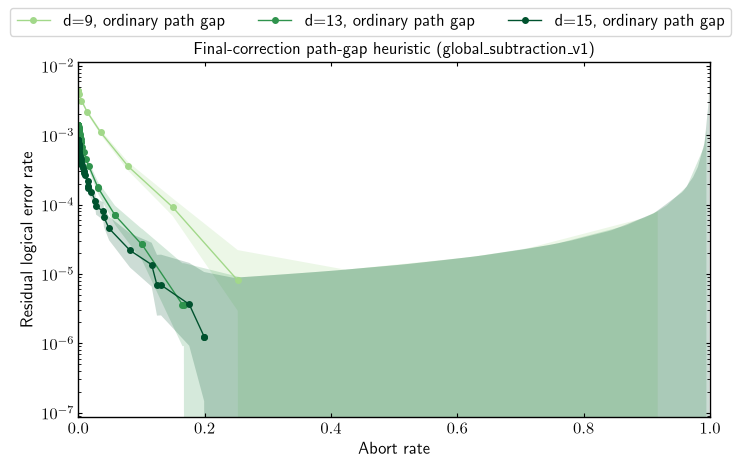

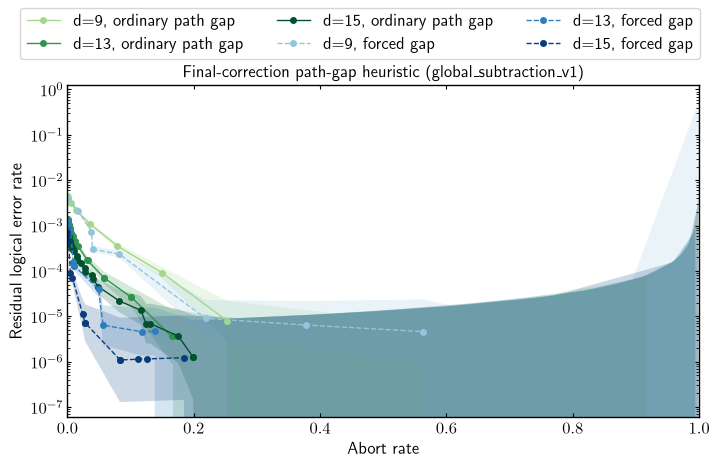

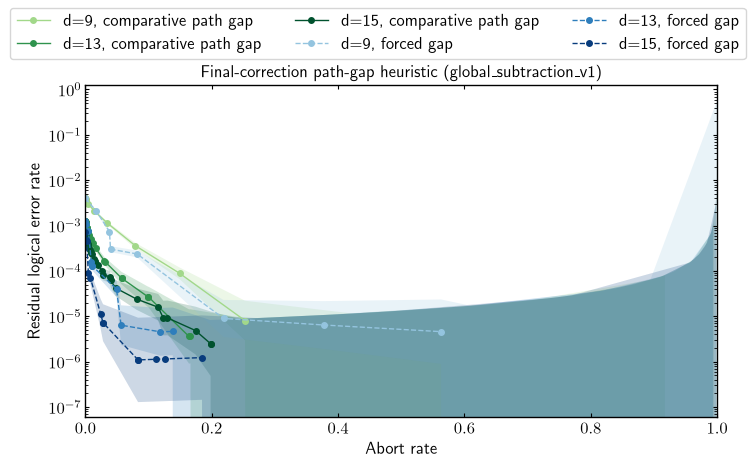

In [6]:
postselection = PostSelectionAnalyzer(style)
figure, ordinary_curve = postselection.plot(dataset, **selection, metrics=('ordinary_path_gap',))
display(figure)
figure, paired_curve = postselection.plot(dataset, **selection, metrics=('ordinary_path_gap', 'forced_gap'))
display(figure)
figure, same_decoder_curve = postselection.plot(dataset, **selection, metrics=('comparative_path_gap', 'forced_gap'))
display(figure)


In [11]:
matched = matched_retention(dataset, **selection, fractions=(1., .9, .75, .5))
matched.to_parquet(run_directory / 'path_gap_matched_retention.parquet', index=False)
display(matched[['distance', 'physical_error_rate', 'metric', 'target_retained',
                 'retained_shots', 'retained_failures', 'residual_logical_error_rate', 'low', 'high']])


,distance,physical_error_rate,metric,target_retained,retained_shots,retained_failures,residual_logical_error_rate,low,high
0,5,0.04,ordinary_path_gap,1.00,100000,1336,0.013360,0.012457,0.014328
1,5,0.04,ordinary_path_gap,0.90,90000,421,0.004678,0.004127,0.005301
2,5,0.04,ordinary_path_gap,0.75,75000,19,0.000253,0.000141,0.000454
3,5,0.04,ordinary_path_gap,0.50,50000,2,0.000040,0.000008,0.000205
4,5,0.04,comparative_path_gap,1.00,100000,1337,0.013370,0.012466,0.014338
5,5,0.04,comparative_path_gap,0.90,90000,415,0.004611,0.004065,0.005230
6,5,0.04,comparative_path_gap,0.75,75000,19,0.000253,0.000141,0.000454
7,5,0.04,comparative_path_gap,0.50,50000,2,0.000040,0.000008,0.000205
8,5,0.04,forced_gap,1.00,100000,1337,0.013370,0.012466,0.014338
9,5,0.04,forced_gap,0.90,90000,410,0.004556,0.004013,0.005171


同一保持率テーブルでは同点境界だけを stable shot ID（結果とは独立）で分割します。threshold 図の「同点を全保持」とは異なる評価です。スコアの丸めはデフォルトで行いません。必要なら各 API の `round_digits` を明示し、全手法で揃えてください。

保存先には全ショットの Parquet、raw-count summary、バッチ別 decode / metric 時間、source snapshot、設定・依存バージョン・実際の外部ソースの provenance、PDF/PNG と解析テーブルが残ります。旧 SWIM データとは独立した新実験です。同じ seed だけでは異なる Stim 版や batch size との bitwise な一致は保証されません。


## Post-selection の定量比較：abort rate・削減率・forced-gap比

このセルは保存データのみを使います。`RUN_NEW_EXPERIMENT=True` の実験セルを再実行する必要はありません。
削減率 = `1 - 選別後LER / 各デコーダの選別前LER`。比 = `path-gapの残存LER / forced-gapの残存LER`（1で同じ）。同一abort率の比較では境界同点をshot IDで分割します。元の図と同じ全同点保持の表も別に表示します。
許容倍率1.25は変更可能な参考基準です。点推定がこの範囲内でも統計的同等性を意味しません。ゼロ失敗・低カウントの扱いは自動生成レポートを確認してください。


In [8]:
from IPython.display import Markdown, display
from color_code_softoutput.analysis.path_gap_comparison import compare_postselection

# 既存の dataset と selection（図と同じ距離・p）を使用。新規サンプリングなし。
abort_rates = (0., .01, .025, .05, .1, .15, .2, .25, .3, .5)
competitive_margin = 1.25  # 残存LERがforced gapの1.25倍以内という参考基準
quantitative = compare_postselection(
    dataset, **selection, abort_rates=abort_rates,
    competitive_margin=competitive_margin, round_digits=None,
    output_directory=dataset.run_directory / 'path_gap_comparison')
comparison = quantitative['comparison']
columns = ['distance', 'physical_error_rate', 'target_abort_rate']
for name in ('ordinary_path_gap', 'comparative_path_gap', 'forced_gap'):
    columns += [f'{name}_actual_abort_rate', f'{name}_residual_ler',
                f'{name}_reduction_rate', f'{name}_retained_failures']
columns += ['ordinary_path_gap_ler_ratio_to_forced', 'comparative_path_gap_ler_ratio_to_forced',
            'ordinary_path_gap_low_count_warning', 'comparative_path_gap_low_count_warning']
print('同じabort rate（境界同点分割）：')
display(comparison.loc[comparison.policy == 'matched_abort', columns])
print('図と同じwhole-tie threshold（actual_abort_rateは手法間で異なる場合があります）：')
display(comparison.loc[comparison.policy == 'whole_ties', columns])
display(Markdown(quantitative['report']))
print('Saved report:', quantitative['report_path'])


同じabort rate（境界同点分割）：


,distance,physical_error_rate,target_abort_rate,ordinary_path_gap_actual_abort_rate,ordinary_path_gap_residual_ler,ordinary_path_gap_reduction_rate,ordinary_path_gap_retained_failures,comparative_path_gap_actual_abort_rate,comparative_path_gap_residual_ler,comparative_path_gap_reduction_rate,comparative_path_gap_retained_failures,forced_gap_actual_abort_rate,forced_gap_residual_ler,forced_gap_reduction_rate,forced_gap_retained_failures,ordinary_path_gap_ler_ratio_to_forced,comparative_path_gap_ler_ratio_to_forced,ordinary_path_gap_low_count_warning,comparative_path_gap_low_count_warning
0,5,0.04,0.000,0.000,0.013710,0.000000,2742.0,0.000,0.013690,0.000000,2738.0,0.000,0.013690,0.000000,2738.0,1.001461,1.000000,False,False
1,5,0.04,0.010,0.010,0.013086,0.045525,2591.0,0.010,0.013076,0.044868,2589.0,0.010,0.012374,0.096148,2450.0,1.057551,1.056735,False,False
2,5,0.04,0.025,0.025,0.011841,0.136322,2309.0,0.025,0.011846,0.134686,2310.0,0.025,0.010185,0.256054,1986.0,1.162638,1.163142,False,False
3,5,0.04,0.050,0.050,0.009895,0.278283,1880.0,0.050,0.009868,0.279151,1875.0,0.050,0.008379,0.387951,1592.0,1.180905,1.177764,False,False
4,5,0.04,0.100,0.100,0.005583,0.592755,1005.0,0.100,0.005533,0.595812,996.0,0.100,0.004672,0.658713,841.0,1.195006,1.184304,False,False
5,5,0.04,0.150,0.150,0.001565,0.885871,266.0,0.150,0.001659,0.878830,282.0,0.150,0.000812,0.940704,138.0,1.927536,2.043478,False,False
6,5,0.04,0.200,0.200,0.001375,0.899708,220.0,0.200,0.001419,0.896366,227.0,0.200,0.000256,0.981282,41.0,5.365854,5.536585,False,False
7,5,0.04,0.250,0.250,0.001260,0.908096,189.0,0.250,0.001327,0.903092,199.0,0.250,0.000260,0.981008,39.0,4.846154,5.102564,False,False
8,5,0.04,0.300,0.300,0.001107,0.919246,155.0,0.300,0.001186,0.913388,166.0,0.300,0.000214,0.984347,30.0,5.166667,5.533333,False,False
9,5,0.04,0.500,0.500,0.000120,0.991247,12.0,0.500,0.000130,0.990504,13.0,0.500,0.000020,0.998539,2.0,6.000000,6.500000,True,True


図と同じwhole-tie threshold（actual_abort_rateは手法間で異なる場合があります）：


,distance,physical_error_rate,target_abort_rate,ordinary_path_gap_actual_abort_rate,ordinary_path_gap_residual_ler,ordinary_path_gap_reduction_rate,ordinary_path_gap_retained_failures,comparative_path_gap_actual_abort_rate,comparative_path_gap_residual_ler,comparative_path_gap_reduction_rate,comparative_path_gap_retained_failures,forced_gap_actual_abort_rate,forced_gap_residual_ler,forced_gap_reduction_rate,forced_gap_retained_failures,ordinary_path_gap_ler_ratio_to_forced,comparative_path_gap_ler_ratio_to_forced,ordinary_path_gap_low_count_warning,comparative_path_gap_low_count_warning
10,5,0.04,0.000,0.000000,0.013710,0.000000,2742.0,0.000000,0.013690,0.000000,2738.0,0.000000,0.013690,0.000000,2738.0,1.001461,1.000000,False,False
11,5,0.04,0.010,0.000000,0.013710,0.000000,2742.0,0.000000,0.013690,0.000000,2738.0,0.000000,0.013690,0.000000,2738.0,1.001461,1.000000,False,False
12,5,0.04,0.025,0.000000,0.013710,0.000000,2742.0,0.000000,0.013690,0.000000,2738.0,0.000000,0.013690,0.000000,2738.0,1.001461,1.000000,False,False
13,5,0.04,0.050,0.000000,0.013710,0.000000,2742.0,0.000000,0.013690,0.000000,2738.0,0.025655,0.010073,0.264176,1963.0,1.361006,1.359020,False,False
14,5,0.04,0.100,0.000000,0.013710,0.000000,2742.0,0.000000,0.013690,0.000000,2738.0,0.025655,0.010073,0.264176,1963.0,1.361006,1.359020,False,False
15,5,0.04,0.150,0.143785,0.001588,0.884144,272.0,0.142260,0.001685,0.876942,289.0,0.025655,0.010073,0.264176,1963.0,0.157681,0.167238,False,False
16,5,0.04,0.200,0.143785,0.001588,0.884144,272.0,0.142260,0.001685,0.876942,289.0,0.157605,0.000297,0.978322,50.0,5.352194,5.676596,False,False
17,5,0.04,0.250,0.143785,0.001588,0.884144,272.0,0.142260,0.001685,0.876942,289.0,0.157605,0.000297,0.978322,50.0,5.352194,5.676596,False,False
18,5,0.04,0.300,0.143785,0.001588,0.884144,272.0,0.142260,0.001685,0.876942,289.0,0.157605,0.000297,0.978322,50.0,5.352194,5.676596,False,False
19,5,0.04,0.500,0.143785,0.001588,0.884144,272.0,0.142260,0.001685,0.876942,289.0,0.157605,0.000297,0.978322,50.0,5.352194,5.676596,False,False


# Path-gap post-selection 定量比較

Run: `/home/quantum_teresheys/workspace/color_code_softoutput/results/20260919_082109_498604_path_gap_test`

削減率 = 1 − 選別後LER / 各デコーダの選別前LER。削減倍率 = 選別前LER / 選別後LER。
残存LER比 = path-gap LER / forced-gap LER（小さいほど良い、1で同じ）。
参考判定の許容倍率は 1.25。これはユーザー指定可能な記述的基準で、統計的な同等性の証明ではありません。

ordinary path-gap 対 forced gap は異なる hard decoder のパイプライン比較。comparative path-gap 対 forced gap は同じ hard decoder のスコア比較。
各手法の残存失敗数・99% Wilson区間は counts.csv に保存。20未満の残存失敗数には低カウント警告を付ける（20は検定基準ではない）。
両方ゼロ失敗でも同等とは判定しない。forced gapがゼロ失敗なら比は未定義。ゼロ失敗時の削減率100%も観測値のみで、真のLERがゼロという意味ではない。

## 同一 abort rate（境界同点のみ shot ID で分割）

| d | p | abort | ordinary 残存失敗 | forced 残存失敗 | ordinary 削減率 | forced 削減率 | ordinary/forced LER | comparative/forced LER | 低カウント |
|---|---|---|---|---|---|---|---|---|---|
| 5 | 0.04 | 0.00% | 2742 | 2738 | 0.00% | 0.00% | 1.001 | 1 | なし |
| 5 | 0.04 | 1.00% | 2591 | 2450 | 4.55% | 9.61% | 1.058 | 1.057 | なし |
| 5 | 0.04 | 2.50% | 2309 | 1986 | 13.63% | 25.61% | 1.163 | 1.163 | なし |
| 5 | 0.04 | 5.00% | 1880 | 1592 | 27.83% | 38.80% | 1.181 | 1.178 | なし |
| 5 | 0.04 | 10.00% | 1005 | 841 | 59.28% | 65.87% | 1.195 | 1.184 | なし |
| 5 | 0.04 | 15.00% | 266 | 138 | 88.59% | 94.07% | 1.928 | 2.043 | なし |
| 5 | 0.04 | 20.00% | 220 | 41 | 89.97% | 98.13% | 5.366 | 5.537 | なし |
| 5 | 0.04 | 25.00% | 189 | 39 | 90.81% | 98.10% | 4.846 | 5.103 | なし |
| 5 | 0.04 | 30.00% | 155 | 30 | 91.92% | 98.43% | 5.167 | 5.533 | なし |
| 5 | 0.04 | 50.00% | 12 | 2 | 99.12% | 99.85% | 6 | 6.5 | あり |
| 7 | 0.04 | 0.00% | 1596 | 1488 | 0.00% | 0.00% | 1.073 | 1 | なし |
| 7 | 0.04 | 1.00% | 1364 | 1331 | 13.67% | 9.65% | 1.025 | 0.9564 | なし |
| 7 | 0.04 | 2.50% | 1024 | 1111 | 34.19% | 23.42% | 0.9217 | 0.8722 | なし |
| 7 | 0.04 | 5.00% | 498 | 676 | 67.15% | 52.18% | 0.7367 | 0.7367 | なし |
| 7 | 0.04 | 10.00% | 376 | 59 | 73.82% | 95.59% | 6.373 | 6.441 | なし |
| 7 | 0.04 | 15.00% | 318 | 42 | 76.56% | 96.68% | 7.571 | 7.524 | なし |
| 7 | 0.04 | 20.00% | 246 | 35 | 80.73% | 97.06% | 7.029 | 7.029 | なし |
| 7 | 0.04 | 25.00% | 173 | 24 | 85.55% | 97.85% | 7.208 | 7.25 | なし |
| 7 | 0.04 | 30.00% | 100 | 15 | 91.05% | 98.56% | 6.667 | 6.533 | あり |
| 7 | 0.04 | 50.00% | 9 | 0 | 98.87% | 100.00% | 未定義 | 未定義 | あり |
| 9 | 0.04 | 0.00% | 933 | 831 | 0.00% | 0.00% | 1.123 | 1 | なし |
| 9 | 0.04 | 1.00% | 665 | 617 | 28.00% | 25.00% | 1.078 | 0.9643 | なし |
| 9 | 0.04 | 2.50% | 415 | 335 | 54.38% | 58.65% | 1.239 | 1.152 | なし |
| 9 | 0.04 | 5.00% | 349 | 67 | 60.63% | 91.51% | 5.209 | 4.851 | なし |
| 9 | 0.04 | 10.00% | 219 | 48 | 73.92% | 93.58% | 4.562 | 4.125 | なし |
| 9 | 0.04 | 15.00% | 88 | 27 | 88.90% | 96.18% | 3.259 | 2.963 | なし |
| 9 | 0.04 | 20.00% | 60 | 8 | 91.96% | 98.80% | 7.5 | 6.875 | あり |
| 9 | 0.04 | 25.00% | 55 | 2 | 92.14% | 99.68% | 27.5 | 25.5 | あり |
| 9 | 0.04 | 30.00% | 40 | 1 | 93.88% | 99.83% | 40 | 36 | あり |
| 9 | 0.04 | 50.00% | 11 | 0 | 97.64% | 100.00% | 未定義 | 未定義 | あり |
| 11 | 0.04 | 0.00% | 483 | 443 | 0.00% | 0.00% | 1.09 | 1 | なし |
| 11 | 0.04 | 1.00% | 270 | 234 | 43.53% | 46.64% | 1.154 | 1.107 | なし |
| 11 | 0.04 | 2.50% | 209 | 39 | 55.62% | 90.97% | 5.359 | 5.231 | なし |
| 11 | 0.04 | 5.00% | 124 | 32 | 72.98% | 92.40% | 3.875 | 3.719 | なし |
| 11 | 0.04 | 10.00% | 69 | 19 | 84.13% | 95.23% | 3.632 | 3.632 | あり |
| 11 | 0.04 | 15.00% | 56 | 1 | 86.36% | 99.73% | 56 | 57 | あり |
| 11 | 0.04 | 20.00% | 40 | 1 | 89.65% | 99.72% | 40 | 39 | あり |
| 11 | 0.04 | 25.00% | 25 | 0 | 93.10% | 100.00% | 未定義 | 未定義 | あり |
| 11 | 0.04 | 30.00% | 11 | 0 | 96.75% | 100.00% | 未定義 | 未定義 | あり |
| 11 | 0.04 | 50.00% | 3 | 0 | 98.76% | 100.00% | 未定義 | 未定義 | あり |

## 記述的な判定（abort > 0 の設定点）

- ordinary_path_gap: {'above_margin_point_estimate': 21, 'within_margin_point_estimate': 10, 'undefined_zero_reference_failures': 5}
- comparative_path_gap: {'above_margin_point_estimate': 21, 'within_margin_point_estimate': 10, 'undefined_zero_reference_failures': 5}

### 距離ごとの読み取り

- d=5, p=0.04: abort 5.00%: ordinary/forced=1.181（残存失敗 1880/1592）; abort 10.00%: ordinary/forced=1.195（残存失敗 1005/841）; abort 20.00%: ordinary/forced=5.366（残存失敗 220/41）
- d=7, p=0.04: abort 5.00%: ordinary/forced=0.7367（残存失敗 498/676）; abort 10.00%: ordinary/forced=6.373（残存失敗 376/59）; abort 20.00%: ordinary/forced=7.029（残存失敗 246/35）
- d=9, p=0.04: abort 5.00%: ordinary/forced=5.209（残存失敗 349/67）; abort 10.00%: ordinary/forced=4.562（残存失敗 219/48）; abort 20.00%: ordinary/forced=7.5（残存失敗 60/8）
- d=11, p=0.04: abort 5.00%: ordinary/forced=3.875（残存失敗 124/32）; abort 10.00%: ordinary/forced=3.632（残存失敗 69/19）; abort 20.00%: ordinary/forced=40（残存失敗 40/1）

ordinary path-gap は全設定でforced gap並みとはいえない。許容倍率を超える点があり、距離・棄却率によって相対性能が変わる。一部の点で比が1以下でも、全体としての優越性は意味しない。

設定点は互いに独立ではなく、この件数は統計検定ではない。距離・abort rateごとに評価し、低カウント領域の順位は確定しない。

## 元の図との対応

元の図は同点を全保持する threshold 曲線。matched_abort 表は境界同点を分けるので、その点が図上の閾値として存在するとは限らない。
whole_ties 表は指定abort予算以下で最大の閾値を選択。actual_abort_rate を確認すること：手法間で同じ棄却率とは限らない。補間で存在しない閾値を作ってはいない。
生スコアはデフォルトで丸めない。浮動小数点の微差も順位に残る。round_digits を変える場合は別出力先を指定し、感度を確認する。

99%区間は点ごとのLER診断であり、比・削減率・手法間差や曲線全体の信頼区間ではない。性能比較は保存ショットの事後的な記述で、較正・普遍的な優越性・統計的同等性を主張しない。


Saved report: /home/quantum_teresheys/workspace/color_code_softoutput/results/20260919_082109_498604_path_gap_test/path_gap_comparison/REPORT.md
